# SHS generation + analysis

In [13]:
# Sequence & structure 
RNA_SEQ =   "AAAAAAAAAAAAAAAAAAAAAAAAAA"
STRUCTURE = "((...)....)(((()).......))"                         # overrides the predictor if set
STRUCTURE_PREDICTOR = "rnafold"          # rnafold, spotrna, rnaformer

# MSA size / reproducibility 
N = 1000
SEED = 42
PDB_ID = "custom"

# Mutation parameters
WOBBLE_PROB            = 0.1 # 0.1
STEM_KEEP_PROB         = 0.0 # 0.99

# Base-triple / multiplet co-mutation (0.0 disables)
TRIPLET_PROB           = 0.0 # 0.0
TRIPLET_KEEP_PROB      = 0.99 # 0.99

# insertions / deletions
INSERTION_PROB_LOOP    = 0.2 # 0.2
DELETION_PROB_LOOP     = 0.2 # 0.8
LONG_INSERTION_PROB    = 0.05 # 0.05
LONG_DELETION_PROB     = 0.05 # 0.05
MAX_INSERTION_FRACTION = 0.1 # 0.1
MAX_DELETION_FRACTION  = 0.1 # 0.1

# Output
OUTPUT_JSON_DIR = "custom_msa_json_output"

# not used in the script 
INSERTION_PROB_STEM    = 0.0
DELETION_PROB_STEM     = 0.0

## Setup

In [14]:
import importlib
import os
import sys
from argparse import Namespace
from pathlib import Path

%matplotlib inline

_candidates = [Path.cwd(), Path.cwd() / "SHS-Generator"]
SHS_DIR = next((p for p in _candidates if (p / "shs_generator.py").exists()), None)
if SHS_DIR is None:
    raise FileNotFoundError("Could not find shs_generator.py.")
SHS_DIR = SHS_DIR.resolve()
os.chdir(SHS_DIR)
if str(SHS_DIR) not in sys.path:
    sys.path.insert(0, str(SHS_DIR))

import shs_generator
import shs_analyzer
importlib.reload(shs_generator)
importlib.reload(shs_analyzer)

print("SHS-Generator dir:", SHS_DIR)

SHS-Generator dir: /home/kaii/bachelor_project/SyntheticEvolution/SHS-Generator


## Generate the SHS

In [15]:
args = Namespace(
    structure_predictor    = None if STRUCTURE else STRUCTURE_PREDICTOR,
    structure              = STRUCTURE,
    rna_seq                = RNA_SEQ,
    protein_seq            = "MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQ",  # placeholder; AF3 JSON needs a protein chain
    input_json_path        = None,
    pdb_id                 = PDB_ID,
    output_json_dir        = OUTPUT_JSON_DIR,
    N                      = N,
    insertion_prob_loop    = INSERTION_PROB_LOOP,
    deletion_prob_loop     = DELETION_PROB_LOOP,
    insertion_prob_stem    = INSERTION_PROB_STEM,
    deletion_prob_stem     = DELETION_PROB_STEM,
    wobble_prob            = WOBBLE_PROB,
    long_insertion_prob    = LONG_INSERTION_PROB,
    long_deletion_prob     = LONG_DELETION_PROB,
    max_insertion_fraction = MAX_INSERTION_FRACTION,
    max_deletion_fraction  = MAX_DELETION_FRACTION,
    stem_keep_prob         = STEM_KEEP_PROB,
    triplet_prob           = TRIPLET_PROB,
    triplet_keep_prob      = TRIPLET_KEEP_PROB,
    seed                   = SEED,
    max_chains             = None,
    plot                   = False,
    print_msa              = False,
    show_plot              = False,
)

generator = shs_generator.MsaGenerator(args)
generator.process()
output_name    = generator.build_output_name()
generated_json = Path(args.output_json_dir) / f"{output_name}.json"
assert generated_json.exists(), f"Expected output not found: {generated_json}"
print("Generated SHS JSON:\n", generated_json)

2026-07-05 19:09:19,767 - INFO - Processing RNA sequence: AAAAAAAAAAAAAAAAAAAAAAAAAA
2026-07-05 19:09:19,769 - INFO - Using provided dot-bracket structure: ((...)....)(((()).......))
2026-07-05 19:09:19,770 - INFO - Predicted pairs: {5: 1, 1: 5, 10: 0, 0: 10, 15: 14, 14: 15, 16: 13, 13: 16, 24: 12, 12: 24, 25: 11, 11: 25}
2026-07-05 19:09:19,771 - INFO - Secondary structure has 6 unique base pairs.
2026-07-05 19:09:19,802 - INFO - ✅ JSON written to: custom_msa_json_output/custom_custom_rnamsa_N1000_seed42_insl_0.2_dell_0.2_inss_0.0_dels_0.0_lins_0.05_ldels_0.05_maxinslen_2_maxdellen_2_wobble_0.1_stemkeep_0.0_None.json


Generated SHS JSON:
 custom_msa_json_output/custom_custom_rnamsa_N1000_seed42_insl_0.2_dell_0.2_inss_0.0_dels_0.0_lins_0.05_ldels_0.05_maxinslen_2_maxdellen_2_wobble_0.1_stemkeep_0.0_None.json


## Analyze & render

Query length: 26  |  MSA rows: 1000  |  covariation matrix: (26, 26)


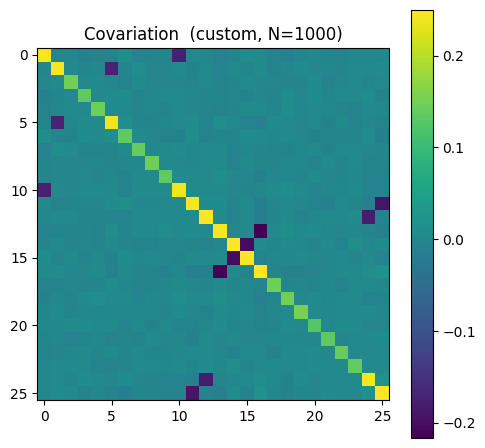

AAAAAAAAAAAAAAAAAAAAAAAAAA
AAAC-U--AGUGAUUAAAUAGUCCUU
AAG--UAG--UAAAUAUAUUCUGUUU
UUAGCA-A--AUUUAUAU-UGCA-AA
AAA-UUG-----UUAUA-GCU-UCAA
UA-GGU-GGCAAAUAUAGU--CACUU
AACCUUUAA-UUAUUAAUCA-GC-UA
AACG-U-U--UAUUUAAGGCAGAUGU
UUGGUAGGU-AUAAAUUCCAU-CUUA
AGCCGU-CGGUUUUAUACGU-----A
AACUGUCCC-----UAAA----GCAA


In [ ]:
seq, msa, covariance = shs_analyzer.compute_covariation(str(generated_json))
print(f"Query length: {len(seq)}  |  MSA rows: {len(msa) + 1}  |  "f"covariation matrix: {covariance.shape}")

fig = shs_analyzer.plot_matrix(
    covariance,
    title=f"Covariation",
    show=True,
)

print(seq)
for i, s in enumerate(msa):
    if i >= 10: break
    print("".join(s))